In [1]:
import jax.numpy as jnp
import jax
import flax.nnx as nnx
import matplotlib.pyplot as plt
from typing import NamedTuple, Callable
from tqdm import tqdm

In [2]:
def f(u: Callable, x_u: jax.Array):
    """ u is a NN """
    # this could just take u as a jax array, but this allows for derivatives
    return 0.5 * u(x_u)**2

def u0(x: jax.Array, uL: jax.Array, uR: jax.Array):
    return jnp.where(x==0, 0.5 * (uL + uR), jnp.where(x > 0, uR, uL))

def utrue(x: jax.Array, t: jax.Array, uL: jax.Array, uR: jax.Array):
    s = jnp.where(t > 0, x / t, jnp.nan)
    rarefaction = jnp.where(s > uR, uR, jnp.where(s < uL, uL, s))
    shock_speed = 0.5 * (uL + uR)
    shock = jnp.where(s < shock_speed, uL, uR)
    ans = jnp.where(jnp.isnan(s), u0(x, uL, uR), jnp.where(uL < uR, rarefaction, shock))
    return ans

def omega(x: jax.Array, t: jax.Array, x0: float, x1: float, T: float):
    norm = 4.0 / (T * (x1 - x0)**2)
    ans = norm * (x - x0) * (x1 - x) * (T - t)
    in_bounds = jnp.logical_and(x >= x0, x<= x1)
    in_time = jnp.logical_and(t >= 0, t <= T)
    return ans * in_bounds * in_time


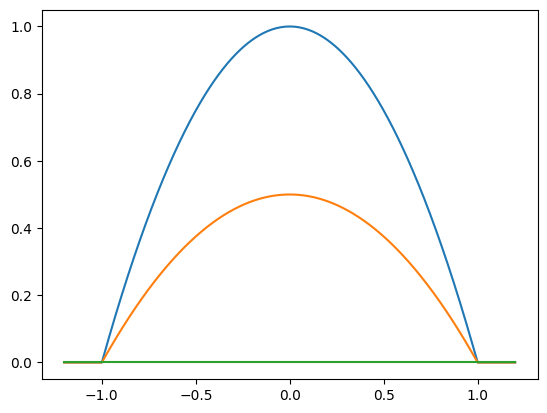

In [3]:
x0 = -1; x1 = 1; T = 1

xlist = jnp.linspace(-1.2, 1.2, 1000)

plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 0),   x0, x1, T))
plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 0.5), x0, x1, T))
plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 1),   x0, x1, T))

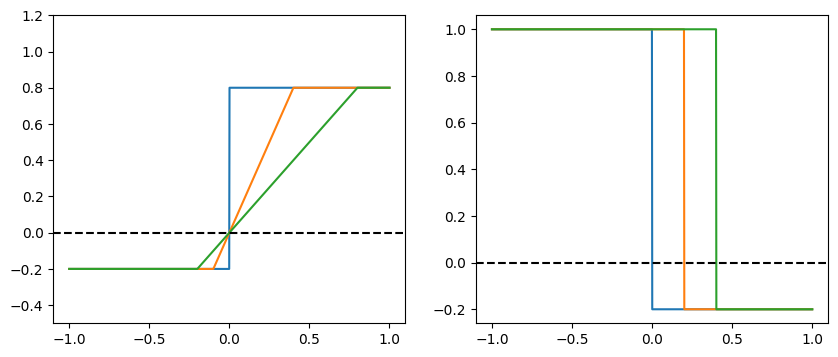

In [4]:
xlist = jnp.linspace(-1, 1, 1000)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for T in [0, 0.5, 1]:
    axs[0].plot(xlist, utrue(xlist, T, -0.2, 0.8))
    axs[1].plot(xlist, utrue(xlist, T, 1, -0.2))

axs[0].set_ylim(-0.5, 1.2)
axs[0].axhline(0, c='k', ls = 'dashed')
# axs[1].set_ylim(-0.5, 1.2)
axs[1].axhline(0, c='k', ls = 'dashed')
plt.show()

In [5]:
class MLP(nnx.Module):
    def __init__(self, dims, *, rngs: nnx.Rngs):
        self.layers = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.relu(layer(x))
        return self.layers[-1](x).squeeze(-1)


def init_nn(in_dim=4, width=32, depth=3, out_dim=1, *, seed=0):
    dims = [in_dim] + [width] * depth + [out_dim]
    return MLP(dims, rngs=nnx.Rngs(seed))

x0 = -1; x1 = 1; T = 1

u_net = init_nn()
phi_net = init_nn(in_dim=2, seed=1)

a = jnp.array([0.1])
x_u = jnp.stack([a, a, a, a], axis=-1)
x_phi = jnp.stack([a, a], axis=-1)
print(u_net(x_u))
print(phi_net(x_phi))

[-0.0380861]
[0.01441721]


In [6]:
def loss(u, phi, x, t, uL, uR, u0, lam_ics=2.0):
    # partial_t u + partial_x f = 0
    x_u = jnp.stack([x, t, uL, uR], axis=-1)
    x_phi = jnp.stack([x, t], axis=-1)
    u_eval = u(x_u)
    f_eval = f(u, x_u)

    grad_phi = jax.vmap(jax.grad(phi))(x_phi)
    phi_x, phi_t = grad_phi[...,0], grad_phi[...,1]

    norm = jnp.mean(phi(x_phi)**2)

    # weak form
    integral_term = jnp.mean(u_eval * phi_t + f_eval * phi_x)

    # BC term
    x_phi_t0 = jnp.stack([x, jnp.full_like(x, 0)], axis=-1)
    bc_term = jnp.mean(u0(x, uL, uR) * phi(x_phi_t0))

    pde_loss = (integral_term + bc_term)**2 / norm

    ics_loss = jnp.mean((u(x_u) - u0(x, uL, uR))**2)

    # print(pde_loss, ics_loss, norm, ics_loss/norm)
    # print(pde_loss, lam_ics*ics_loss)

    return pde_loss + lam_ics * ics_loss

In [7]:
a = jnp.array([0.1])

# loss(lambda x: u_net(x) + u0(a, a, a), phi_net, a, a, a, a, u0)
loss(u_net, phi_net, a, a, a, a, u0, lam_ics=50.0)

Array(0.96411175, dtype=float32)

In [8]:
from jax import random as jr

class R2QuasirandomSampler:
    """R2 quasirandom samples in (drho, dp, du)."""

    # R2 quasirandom additive recurrence. Golden ratios for d=1..12.
    _R2_GOLDEN = jnp.array([
        1.6180339887498949, 1.3247179572447463, 1.2207440846057596,
        1.1673039782614185, 1.1347241384015194, 1.1127756842787053,
        1.0969815577985598, 1.0850702454914507, 1.0757660660868371,
        1.0682971889208415, 1.0621691678642553, 1.0570505752212287,
    ])

    NDIM = 3

    def draw_batch(self, rng, batch_size: int, dim: int, bounds: jax.Array) -> jnp.ndarray:
        g = self._R2_GOLDEN[dim - 1]
        powers = jnp.arange(1, dim + 1, dtype=jnp.float32)
        a = g ** (-powers)
        x0 = jr.uniform(rng, (dim,), minval=0.0, maxval=1.0)
        n = jnp.arange(batch_size, dtype=jnp.float32)[:, None]
        out_unit = jnp.mod(x0[None, :] + n * a[None, :], 1.0)
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        # Broadcast lo/hi so shapes work out
        return lo + (hi - lo) * out_unit
    
    def draw_xtu_batch(self, rng_ur, rng_xt, batch_size: int, nprob: int, bounds_ur: jax.Array, bounds_xt: jax.Array):
        ur = self.draw_batch(rng_ur, nprob, dim=2, bounds=bounds_ur)
        xt = self.draw_batch(rng_xt, batch_size, dim=2, bounds=bounds_xt)
        uL_, uR_ = ur[:, 0], ur[:, 1]
        x_, t_ = xt[:, 0], xt[:, 1]

        uL = jnp.repeat(uL_, batch_size)
        uR = jnp.repeat(uR_, batch_size)
        x = jnp.tile(x_, nprob)
        t = jnp.tile(t_, nprob)

        x_u = jnp.stack([x, t, uL, uR], axis=-1)
        x_phi = jnp.stack([x, t], axis=-1)

        return x_u, x_phi
 

In [9]:
# import matplotlib.pyplot as plt

# sampler = R2QuasirandomSampler()
# key = jax.random.PRNGKey(0)
# keys = jr.split(key, 100)  # just in case

# ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
# xt_bounds = jnp.array([[x0, x1], [0.0, T]])

# # batch_sizes = jnp.array([2**N for N in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]])
# batch_sizes = jnp.array([2**N for N in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
# # nprobs = jnp.array([2**N for N in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]])
# nprobs = jnp.array([2**N for N in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

# print('max: ', batch_sizes[-1]*nprobs[-1])

# loss_matrix = jnp.zeros((len(batch_sizes), len(nprobs)))

# u_net = init_nn()
# phi_net = init_nn(in_dim=2, seed=1)
# phi = lambda x: omega(x[...,0], x[...,1], x0, x1, T) * phi_net(x)

# for i, bs in enumerate(tqdm(batch_sizes)):
#     for j, npb in enumerate(nprobs):
#         # fresh seed for each grid cell for fairness
#         key_ur, key_xt = jr.split(jr.fold_in(keys[0], i * 100 + j))
#         x_u, x_phi = sampler.draw_xtu_batch(key_ur, key_xt, bs, npb, ur_bounds, xt_bounds)
#         x, t, uL, uR = x_u[...,0], x_u[...,1], x_u[...,2], x_u[...,3]
        
#         # u = lambda x: u_net(x) + u0(x[...,0], uL, uR)
#         loss_matrix = loss_matrix.at[i, j].set(loss(u_net, phi, x, t, uL, uR, u0, lam_ics=2.0))

# # Compute reference value (largest batch/nprob)
# ref_val = float(loss_matrix[-1, -1])

# # i got this ref val from the largest batch sizes from above, but trimmed since they dont fit on my laptop's memory
# # ref_val = 0.08620528876781464
# relative_error = (loss_matrix - ref_val) / jnp.abs(ref_val)

# fig, ax = plt.subplots(figsize=(7, 5))
# im = ax.imshow(relative_error, origin="lower", aspect="auto",
#                cmap="bwr", vmin=-0.1, vmax=0.1)
# ax.set_xlabel("nprob")
# ax.set_ylabel("batch_size")
# ax.set_title("Relative Loss Error\nvs. batch_size, nprob\n(wrt largest batch/nprob)")
# plt.colorbar(im, ax=ax, label="Relative Error")
# plt.show()

In [25]:
import optax
from tqdm import tqdm

x0 = -1; x1 = 1; T = 1

u_net = init_nn()
phi_net = init_nn(in_dim=2, seed=1)

lr_u   = 1e-2 ; n_steps_u   = 1
lr_phi = 1e-2 ; n_steps_phi = 1

lam_ics = 10.0

nprob = 2**9
batch_size = 2**10
opt_u =   nnx.Optimizer(u_net,   optax.adamw(lr_u),                                  wrt=nnx.Param)
opt_phi = nnx.Optimizer(phi_net, optax.chain(optax.scale(-1.0), optax.adam(lr_phi)), wrt=nnx.Param)

@nnx.jit
def train_step_u(u_net, phi_net, optimizer, key, lam_ics=2.0):
    # Sample nprob (uL, uR) pairs and batch_size (x, t) points, then take their cross product.
    sampler = R2QuasirandomSampler()
    key_ur, key_xt = jr.split(key)
    ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
    xt_bounds = jnp.array([[x0, x1], [0.0, T]])
    
    x_u, x_phi = sampler.draw_xtu_batch(key_ur, key_xt, batch_size, nprob, ur_bounds, xt_bounds)
    x, t, uL, uR = x_u[...,0], x_u[...,1], x_u[...,2], x_u[...,3]

    phi = lambda x: omega(x[...,0], x[...,1], x0, x1, T) * phi_net(x)
    # loss_val, grads = nnx.value_and_grad(lambda u_net: loss(lambda x: u_net(x) + u0(x[...,0], uL, uR), 
    # phi, x, t, uL, uR, u0, lam_ics=2.0))(u_net)
    loss_val, grads = nnx.value_and_grad(lambda u_net: loss(u_net, phi, x, t, uL, uR, u0, lam_ics=lam_ics))(u_net)
    optimizer.update(u_net, grads)

    return loss_val, u_net

@nnx.jit
def train_step_phi(u_net, phi_net, optimizer, key, lam_ics=2.0):
    # Sample nprob (uL, uR) pairs and batch_size (x, t) points, then take their cross product.
    sampler = R2QuasirandomSampler()
    key_ur, key_xt = jr.split(key)
    ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
    xt_bounds = jnp.array([[x0, x1], [0.0, T]])
    
    x_u, x_phi = sampler.draw_xtu_batch(key_ur, key_xt, batch_size, nprob, ur_bounds, xt_bounds)
    x, t, uL, uR = x_u[...,0], x_u[...,1], x_u[...,2], x_u[...,3]

    # u = lambda x: u_net(x) + u0(x[...,0], uL, uR)
    loss_val, grads = nnx.value_and_grad(
            lambda pn: loss(u_net, lambda x: omega(x[...,0], x[...,1], x0, x1, T) * pn(x), 
                            x, t, uL, uR, u0, lam_ics=lam_ics)
        )(phi_net)
    optimizer.update(phi_net, grads)

    return loss_val, phi_net

def train_u(u_net, phi_net, optimizer, n_steps, key, losses=[], use_tqdm=False, lam_ics=2.0):
    if use_tqdm:
        pbar = tqdm(range(n_steps), desc="Minimizing u")
    else:
        pbar = range(n_steps)

    for step in pbar:
        key, sub = jax.random.split(key)
        loss_val, u_net = train_step_u(u_net, phi_net, optimizer, sub, lam_ics=lam_ics)
        losses.append(float(loss_val))
        if step % 10 == 0 and use_tqdm:
            pbar.set_postfix(loss=losses[-1])
    
    return losses, u_net

def train_phi(u_net, phi_net, optimizer, n_steps, key, losses=[], use_tqdm=False, lam_ics=2.0):
    if use_tqdm:
        pbar = tqdm(range(n_steps), desc="Minimizing u")
    else:
        pbar = range(n_steps)

    for step in pbar:
        key, sub = jax.random.split(key)
        loss_val, phi_net = train_step_phi(u_net, phi_net, optimizer, sub, lam_ics=lam_ics)
        losses.append(float(loss_val))
        if step % 10 == 0 and use_tqdm:
            pbar.set_postfix(loss=losses[-1])
    
    return losses, phi_net

key = jax.random.PRNGKey(0)
losses_u = []
losses_phi = []
# u_net_trace = [u_net]

# import copy

losses_u, u_net = train_u(u_net, phi_net, opt_u, n_steps_u, key, losses=losses_u, lam_ics=lam_ics)
# u_net_trace.append(copy.deepcopy(u_net))

losses_phi = []

for i in tqdm(range(2000)):
    key, sub_phi = jax.random.split(key)
    losses_phi, phi_net = train_phi(u_net, phi_net, opt_phi, n_steps_phi, sub_phi, losses=losses_phi, lam_ics=lam_ics)
    key, sub_u = jax.random.split(key)
    losses_u, u_net = train_u(u_net, phi_net, opt_u, n_steps_u, sub_u, losses=losses_u, lam_ics=lam_ics)
    # u_net_trace.append(copy.deepcopy(u_net))

    if i % 100 == 0:
        phi_net = init_nn(in_dim=2, seed=i)
        lr_phi *= 0.5
        lr_u *= 0.5
        opt_phi = nnx.Optimizer(phi_net, optax.chain(optax.scale(-1.0), optax.adam(lr_phi)), wrt=nnx.Param)
        opt_u   = nnx.Optimizer(u_net, optax.adamw(lr_u), wrt=nnx.Param)
   

100%|██████████| 2000/2000 [18:27<00:00,  1.81it/s]


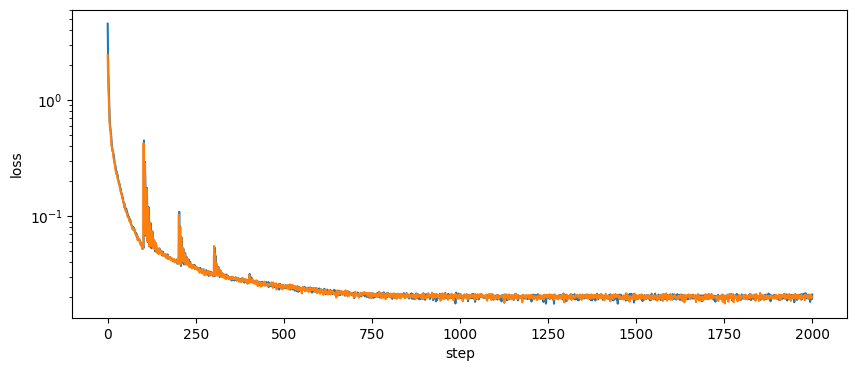

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# was at 200, 0.3
ax.plot(losses_u)
ax.plot(losses_phi)
ax.set(yscale='log', xlabel='step', ylabel='loss')
plt.show()

0.00437831


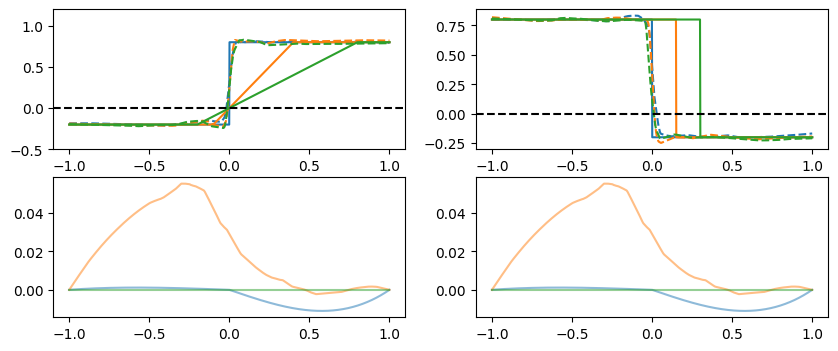

In [31]:
xlist = jnp.linspace(-1, 1, 1000)

fig, axs = plt.subplots(2, 2, figsize=(10, 4))

u = u_net

key = jr.split(key)[0]
sampler = R2QuasirandomSampler()
bs = 2**10
npb = 2**9
ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
xt_bounds = jnp.array([[x0, x1], [0.0, T]])
x_u, x_phi = sampler.draw_xtu_batch(key, key, bs, npb, ur_bounds, xt_bounds)
x, t, uL, uR = x_u[...,0], x_u[...,1], x_u[...,2], x_u[...,3]

phi = lambda x: omega(x[...,0], x[...,1], -1, 1, 1) * phi_net(x)
print(loss(u, phi, x, t, uL, uR, u0, lam_ics=2.0))

for T in [0, 0.5, 1]:
    uL = -0.2 ; uR = 0.8
    l = axs[0][0].plot(xlist, utrue(xlist, T, uL, uR))
    uhat = u(jnp.stack([xlist, jnp.full_like(xlist, T), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1))
    axs[0][0].plot(xlist, uhat, '--', c=l[0].get_color())

    axs[1][0].plot(xlist, phi(jnp.stack([xlist, jnp.full_like(xlist, T)], axis=-1)), c=l[0].get_color(), alpha=0.5)

    uL = 0.8 ; uR = -0.2
    l = axs[0][1].plot(xlist, utrue(xlist, T, uL, uR))
    uhat = u(jnp.stack([xlist, jnp.full_like(xlist, T), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1))
    axs[0][1].plot(xlist, uhat, '--', c=l[0].get_color())
    axs[1][1].plot(xlist, phi(jnp.stack([xlist, jnp.full_like(xlist, T)], axis=-1)), c=l[0].get_color(), alpha=0.5)


axs[0][0].set_ylim(-0.5, 1.2)
axs[0][0].axhline(0, c='k', ls = 'dashed')
# axs[0][1].set_ylim(-0.5, 1.2)
axs[0][1].axhline(0, c='k', ls = 'dashed')
plt.show()

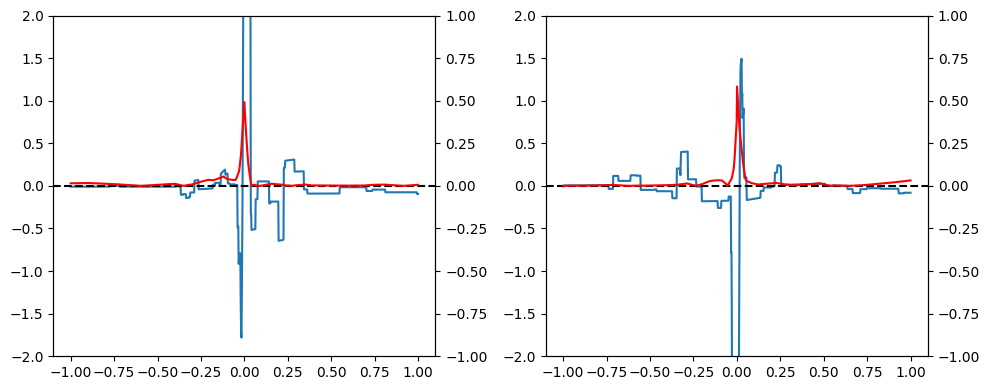

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for uL, uR, ax in zip([-0.2, 0.8], [0.8, -0.2], axs):

    xlist = jnp.linspace(-1, 1, 1000)
    x_u = jnp.stack([xlist, jnp.full_like(xlist, 0.5), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1)
    x_u_t0 = jnp.stack([xlist, jnp.full_like(xlist, 0.), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1)

    grad_u = jax.vmap(jax.grad(u))(x_u)
    u_t = grad_u[...,1]

    fu = lambda x_u: f(u, x_u)
    grad_f = jax.vmap(jax.grad(fu))(x_u)
    f_x = grad_f[...,0]

    u_eval = u(x_u_t0)
    u0_eval = u0(xlist, uL, uR)

    ax.plot(xlist, u_t + f_x)
    ax2 = ax.twinx()
    ax2.plot(xlist, jnp.sqrt((u_eval - u0_eval)**2), c='r')

    ax.set(ylim=(-2, 2))
    ax2.set(ylim=(-1, 1))

    ax.axhline(0, c='k', ls = 'dashed')

fig.tight_layout()